# **`Project 2: Team Thomas Allinson`**

### **Objective**: Analyze the comparative costs of a vegan diet versus an omnivorous diet within the American population, with a specific focus on their environmental impact.

#### Group Members:
> Johann: johann.dicken@berkeley.edu <br>
> Laure: laureho@berkeley.edu <br>
> Reily: reilyjean@berkeley.edu <br>
> Carmen: carmenvega@berkeley.edu <br>
> Steven: k1519632@berkeley.edu <br>
> Xinyu: xzhou60@berkeley.edu 

### **[A]: Description of population of interest**

The project looks at the cost differences between vegan and omnivorous diets in the U.S., focusing on their environmental impact. It examines factors like water consumption, CO2 emissions, and land use tied to different diets. Specifically, we are concentrating on the demographic of women in the 19-30 age range.

### **[A]: Dietary Reference Intakes**

In [82]:
apikey = "KNqUDtV7Kcktiuheo3EoNhB0zDlCevFAdqZrKgdj" 
%pip install -r requirements.txt --upgrade
%pip install wbdata
import fooddatacentral as fdc
import pandas as pd
import numpy as np
import re
from  scipy.optimize import linprog as lp
import wbdata
import sys
import io
import warnings
warnings.simplefilter("ignore")

  Using cached gspread-6.2.0-py3-none-any.whl.metadata (11 kB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [26]:
# Import Dietary Requirements spreadsheet data as a pd.DataFrame
diet_min = pd.read_csv('Dietary_Requirements.csv')
diet_min.head()

,Nutrition,Source,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
0,Energy,---,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
1,Protein,RDA,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
2,"Fiber, total dietary",---,14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
3,"Folate, DFE",RDA,150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
4,"Calcium, Ca",RDA,700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0


Dietary function takes 2 arguments: `age`, a positive integer, and `sex`, a string (not case-senstitive) with the classification of male, female, or child.

In [27]:
def dietary_ref(age, sex):

    # Validate age input
    if not isinstance(age, int) or age <= 0:
        return "Incorrect age input. Please enter a positive integer for the age."
    
    # Normalize and validate sex input
    sex = sex.lower()
    if sex not in ['male', 'female', 'child']:
        return "Incorrect sex input. Input must be Male, Female, or Child."
    
    # Determine the appropriate column based on age and sex
    if sex == 'child':
        if age <= 3:
            col_name = 'C 1-3'
        elif age <= 8:
            col_name = 'C 4-8'
        else:
            return "Age out of range for child category."
    else:
        if age <= 8:
            col_name = f"{'F' if sex == 'female' else 'M'} 4-8"
        elif age <= 13:
            col_name = f"{'F' if sex == 'female' else 'M'} 9-13"
        elif age <= 18:
            col_name = f"{'F' if sex == 'female' else 'M'} 14-18"
        elif age <= 30:
            col_name = f"{'F' if sex == 'female' else 'M'} 19-30"
        elif age <= 50:
            col_name = f"{'F' if sex == 'female' else 'M'} 31-50"
        else:
            col_name = f"{'F' if sex == 'female' else 'M'} 51+"
    
    # Extract and return the relevant nutrient recommendations
    if col_name in diet_min.columns:
        return diet_min[['Nutrition', col_name]].set_index('Nutrition')[col_name]
    else:
        return "Matching column not found in DataFrame. Check the column names."

In [28]:
# Example usage
dietary_ref(15, 'Male')

Nutrition
Energy                            2200.0
Protein                             52.0
Fiber, total dietary                30.8
Folate, DFE                        400.0
Calcium, Ca                       1300.0
Carbohydrate, by difference        130.0
Iron, Fe                            11.0
Magnesium, Mg                      410.0
Niacin                              16.0
Phosphorus, P                     1250.0
Potassium, K                      4700.0
Riboflavin                           1.3
Thiamin                              1.2
Vitamin A, RAE                     900.0
Vitamin B-12                         2.4
Vitamin B-6                          1.3
Vitamin C, total ascorbic acid      75.0
Vitamin E (alpha-tocopherol)        15.0
Vitamin K (phylloquinone)           75.0
Zinc, Zn                            11.0
Name: M 14-18, dtype: float64

In [29]:
# Unit test: verify column name matches the expected group
assert dietary_ref(15, 'Male').name == 'M 14-18'

In [30]:
# Women in the 19-30 age range
dietary_ref(20, 'Female')

Nutrition
Energy                            2000.0
Protein                             46.0
Fiber, total dietary                28.0
Folate, DFE                        400.0
Calcium, Ca                       1000.0
Carbohydrate, by difference        130.0
Iron, Fe                            18.0
Magnesium, Mg                      310.0
Niacin                              14.0
Phosphorus, P                      700.0
Potassium, K                      4700.0
Riboflavin                           1.1
Thiamin                              1.1
Vitamin A, RAE                     700.0
Vitamin B-12                         2.4
Vitamin B-6                          1.3
Vitamin C, total ascorbic acid      75.0
Vitamin E (alpha-tocopherol)        15.0
Vitamin K (phylloquinone)           90.0
Zinc, Zn                             8.0
Name: F 19-30, dtype: float64

#### Description - The plot represents the nutritional requirements for a 20-year-old female, displaying various nutrients along with their recommended daily values. Potassium (K) stands out with the highest nutrient value, followed by Energy, Calcium, Phosphorus, and Vitamin A. The graph provides a clear visual comparison of how much of each nutrient is required, with some nutrients like Potassium having significantly higher values compared to others. The chart is color-coded, showing the distribution of these values, and offers insight into the nutrient priorities for a female in this age group.

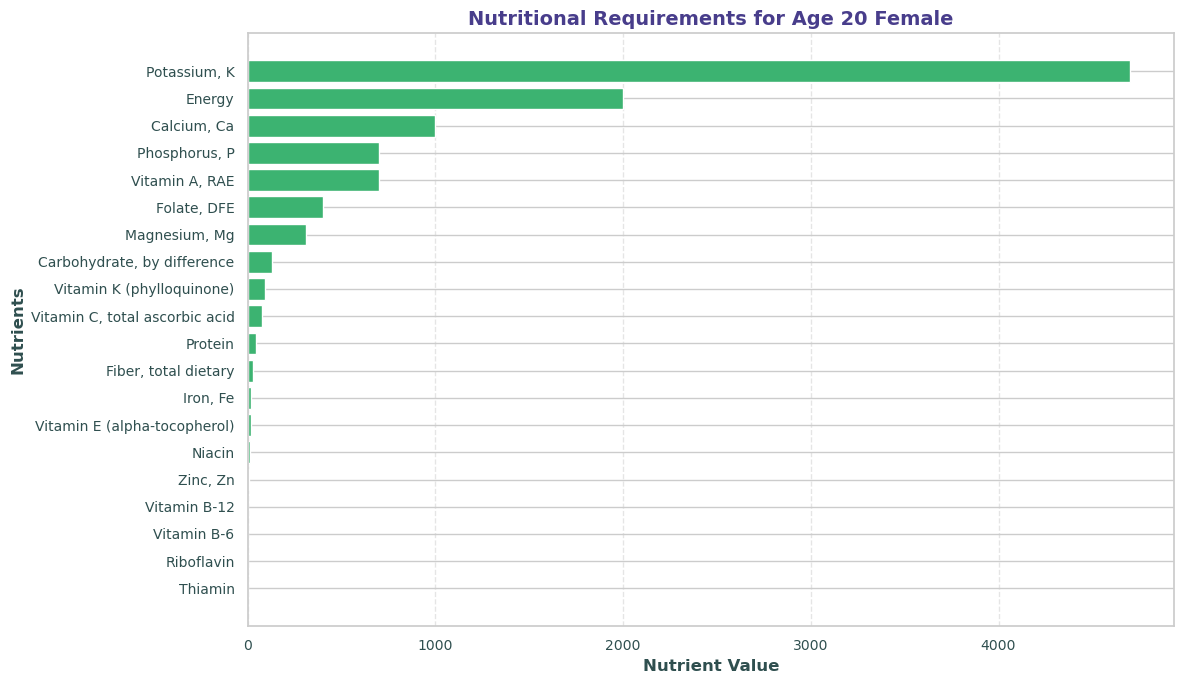

In [31]:
# Women in the 19-30 age range Plot
import matplotlib.pyplot as plt

nutrients = {
    "Energy": 2000.0,
    "Protein": 46.0,
    "Fiber, total dietary": 28.0,
    "Folate, DFE": 400.0,
    "Calcium, Ca": 1000.0,
    "Carbohydrate, by difference": 130.0,
    "Iron, Fe": 18.0,
    "Magnesium, Mg": 310.0,
    "Niacin": 14.0,
    "Phosphorus, P": 700.0,
    "Potassium, K": 4700.0,
    "Riboflavin": 1.1,
    "Thiamin": 1.1,
    "Vitamin A, RAE": 700.0,
    "Vitamin B-12": 2.4,
    "Vitamin B-6": 1.3,
    "Vitamin C, total ascorbic acid": 75.0,
    "Vitamin E (alpha-tocopherol)": 15.0,
    "Vitamin K (phylloquinone)": 90.0,
    "Zinc, Zn": 8.0
}

nutrients_sorted = dict(sorted(nutrients.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 7))
plt.barh(list(nutrients_sorted.keys()), list(nutrients_sorted.values()), color='mediumseagreen')

plt.xlabel("Nutrient Value", fontsize=12, fontweight='bold', color='darkslategray')
plt.ylabel("Nutrients", fontsize=12, fontweight='bold', color='darkslategray')
plt.title("Nutritional Requirements for Age 20 Female", fontsize=14, fontweight='bold', color='darkslateblue')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.xticks(fontsize=10, color='darkslategray')
plt.yticks(fontsize=10, color='darkslategray')

plt.tight_layout()
plt.show()

### **[A]: Data on prices for different foods**

> ### OMNIVORE DIET

DataFrame of 126 different foods, with data on their carbon and water footprints, average price, and vegan classification: `animal product` or `plant-based`.

In [32]:
# Load the CSV file into a DataFrame
df = pd.read_csv('food_and_prices.csv')

# Define a regex pattern for common animal products
animal_product_pattern = r'\b(butter|cheese|milk|kefir|whey|eggnog|mascarpone|mozzarella|stracchino|parmigiano|beef|turbot|cod|ricotta|chicken|carp|salmon|bacon|trout|mealworms|dulce|pork|egg|fish|lamb|turkey|turtle|breast|mollusks|frog|thigh|yogurt|honey|gelatin|cream|lard|sausage|anchovy|shellfish|shrimp|mayo|ham|meat)\b'

# Create a new column 'animal product' that marks items based on the pattern
df['animal product'] = df['Food commodity ITEM'].apply(
    lambda x: 'animal product' if re.search(animal_product_pattern, str(x), re.IGNORECASE) else 'plant-based'
)

# Display the updated DataFrame
df.rename(columns={'Food commodity ITEM': 'Food'}, inplace=True)
df = df[df['Food'] != 'YEAST COMPRESSED*']
df['Average Price per 100g (USD)'] = df['Average Price per kg (USD)']/10
#df.drop('YEAST COMPRESSED*'
#df[df['animal product'] == 'plant-based'].head(100)
df.set_index('Food', inplace=True)
df

,Carbon Footprint kg CO2eq/kg or l of food ITEM,Water Footprint liters water/kg o liter of food ITEM,FDC ID,FDC Food Name,Average Price per kg (USD),animal product,Average Price per 100g (USD)
Food,,,,,,,
CHOCOLATE OR CREAM FILLED COOKIES**,1.53,2902.0,2707915,"Cookie, chocolate or fudge",10.80,animal product,1.080
SIMPLE COOKIES**,1.39,1723.0,2707964,"Cookie, shortbread",10.80,plant-based,1.080
BREAD MULTICEREAL**,0.70,771.0,2707777,"Bread, multigrain",4.24,plant-based,0.424
BREAD PLAIN**,0.89,1031.0,174929,"Bread, sticks, plain",4.24,plant-based,0.424
BREAD WHOLE**,0.77,887.0,2707709,"Bread, whole wheat",4.24,plant-based,0.424
...,...,...,...,...,...,...,...
CARP,1.76,2364.0,2706233,"Fish, carp",8.80,animal product,0.880
COD,3.08,2782.0,2099857,COD,12.00,animal product,1.200
SALMON,3.37,2193.0,2016166,SALMON,20.00,animal product,2.000


#### Description - The three bar plots compare the top 10 food items in an omnivore diet based on their carbon footprint, water footprint, and average price per 100g. Animal-based products like beef and lamb rank high in both carbon and water footprints, highlighting their significant environmental impact. Meanwhile, premium items like Parmigiano Reggiano, salmon, and turbot are among the most expensive. These visualizations offer a clear perspective on the environmental costs and price of various food choices in an omnivore diet.

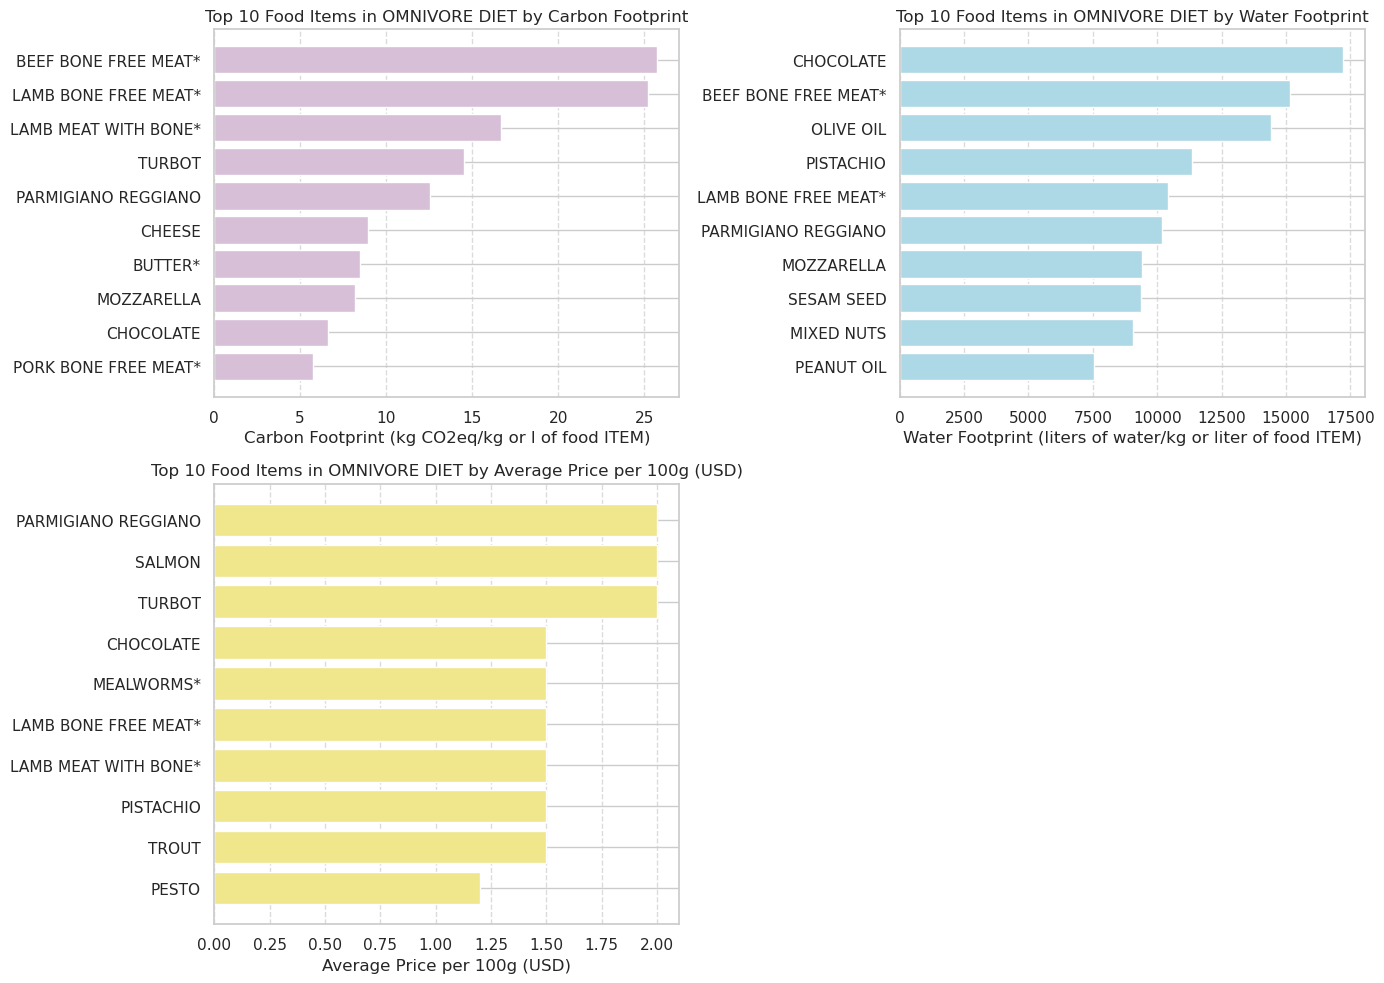

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})
fig.delaxes(axes[1, 1])

carbon_color = "#D8BFD8"
water_color = 'lightblue'
price_color = 'khaki'

top_carbon = df.nlargest(10, 'Carbon Footprint kg CO2eq/kg or l of food ITEM')
axes[0, 0].barh(top_carbon.index, top_carbon['Carbon Footprint kg CO2eq/kg or l of food ITEM'], color=carbon_color)
axes[0, 0].set_xlabel("Carbon Footprint (kg CO2eq/kg or l of food ITEM)")
axes[0, 0].set_title("Top 10 Food Items in OMNIVORE DIET by Carbon Footprint")
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.7)

top_water = df.nlargest(10, 'Water Footprint liters water/kg o liter of food ITEM')
axes[0, 1].barh(top_water.index, top_water['Water Footprint liters water/kg o liter of food ITEM'], color=water_color)
axes[0, 1].set_xlabel("Water Footprint (liters of water/kg or liter of food ITEM)")
axes[0, 1].set_title("Top 10 Food Items in OMNIVORE DIET by Water Footprint")
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.7)

top_price_100g = df.nlargest(10, 'Average Price per 100g (USD)')
axes[1, 0].barh(top_price_100g.index, top_price_100g['Average Price per 100g (USD)'], color=price_color)
axes[1, 0].set_xlabel("Average Price per 100g (USD)")
axes[1, 0].set_title("Top 10 Food Items in OMNIVORE DIET by Average Price per 100g (USD)")
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [34]:
summary_df = df.groupby("animal product").agg(
    avg_carbon_footprint=('Carbon Footprint kg CO2eq/kg or l of food ITEM', 'mean'),
    avg_water_footprint=('Water Footprint liters water/kg o liter of food ITEM', 'mean'),
    avg_price_per_100g=('Average Price per 100g (USD)', 'mean')
).reset_index()

summary_df.columns = ["product", "avg_carbon_footprint (kg CO2eq/kg)", 
                      "avg_water_footprint (liters/kg)", "avg_price (USD/100g)"]

summary_df

,product,avg_carbon_footprint (kg CO2eq/kg),avg_water_footprint (liters/kg),avg_price (USD/100g)
0,animal product,7.340417,5022.083333,1.128125
1,plant-based,0.910392,2130.643137,0.473980


#### Description - The three bar plots compare animal-based and plant-based foods based on their average carbon footprint, water footprint, and price per 100g. Animal-based foods have significantly higher environmental impacts, with a carbon footprint of 7.34 kg CO2eq/kg and a water footprint of 5022 liters/kg, compared to plant-based foods, which have a much lower impact. However, animal-based foods are also more expensive, with an average price of 1.13 USD per 100g, compared to 0.47 USD for plant-based foods. These observations suggest that while plant-based diets are more sustainable and affordable, animal-based products carry a higher environmental cost.

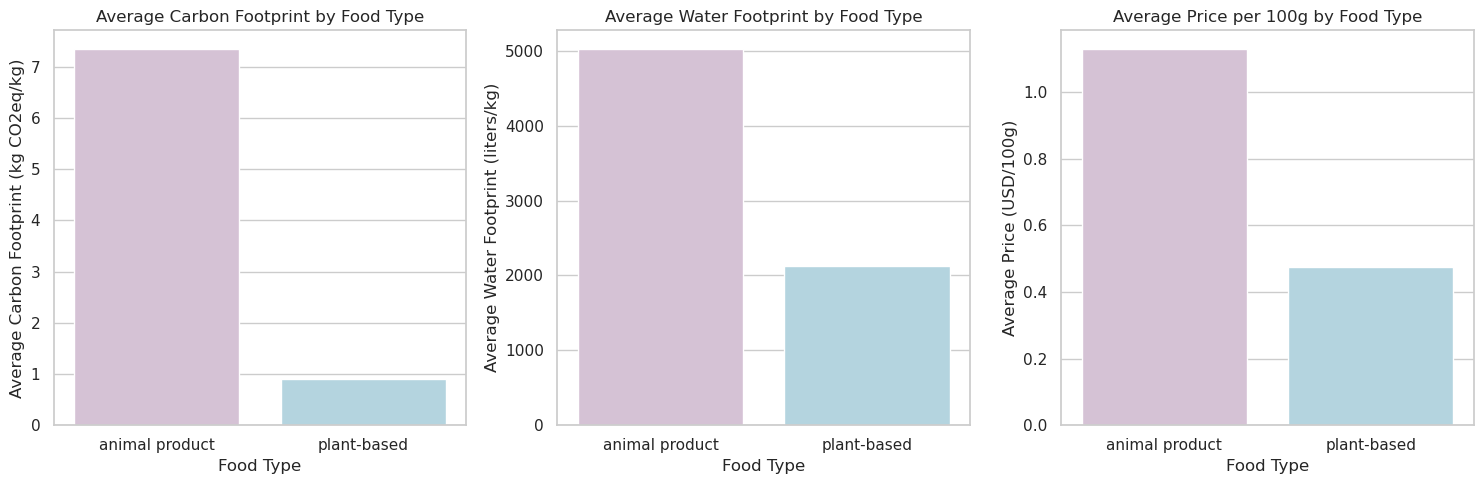

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
warnings.filterwarnings("ignore")

summary_df = pd.DataFrame({
    "product": ["animal product", "plant-based"],
    "avg_carbon_footprint (kg CO2eq/kg)": [7.340417, 0.910392],
    "avg_water_footprint (liters/kg)": [5022.083333, 2130.643137],
    "avg_price (USD/100g)": [1.128125, 0.473980]
})

colors = ["#D8BFD8", "#ADD8E6"] 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x="product", y="avg_carbon_footprint (kg CO2eq/kg)", data=summary_df, palette=colors, ax=axes[0])
axes[0].set_title("Average Carbon Footprint by Food Type")
axes[0].set_xlabel("Food Type")
axes[0].set_ylabel("Average Carbon Footprint (kg CO2eq/kg)")

sns.barplot(x="product", y="avg_water_footprint (liters/kg)", data=summary_df, palette=colors, ax=axes[1])
axes[1].set_title("Average Water Footprint by Food Type")
axes[1].set_xlabel("Food Type")
axes[1].set_ylabel("Average Water Footprint (liters/kg)")

sns.barplot(x="product", y="avg_price (USD/100g)", data=summary_df, palette=colors, ax=axes[2])
axes[2].set_title("Average Price per 100g by Food Type")
axes[2].set_xlabel("Food Type")
axes[2].set_ylabel("Average Price (USD/100g)")

plt.tight_layout()
plt.show()

### **[A]: Nutritional content of different foods**

Returns DataFrame of nutrient values for all foods we are evaluating.

In [36]:
D = {}
count = 0
for food in df.index:
        try:
            FDC = df.loc[df.index==food,:]['FDC ID'][0]
            count+=1
            D[food] = fdc.nutrients(apikey,FDC).Quantity
            #print(D[food])
            #print(food)
        except AttributeError:
            warnings.warn(f"Couldn't find FDC Code {FDC} for food {food}.")
    
D = pd.DataFrame(D,dtype=float)
D

,BREAD WHOLE**,FLAVORED CRACKERS**,PLAIN CRACKERS**,WHOLEGRAIN CRACKERS**,CRISPBREAD**,KETCHUP,EGG PASTA*,ORANGE JUICE,OAT MEAL,CHOCOLATE,...,EGGPLANT,PEPPER,PUMPKIN,TOMATO,ZUCCHINI,CARP,COD,SALMON,TROUT,TURBOT
Alanine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.971
"Alcohol, ethyl",0.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN,0.00,NaN,...,0.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN
Amino acids,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
Arginine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.960
Ash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vitamin K (Dihydrophylloquinone),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vitamin K (phylloquinone),7.80,NaN,69.30,36.00,NaN,3.00,NaN,NaN,0.60,NaN,...,24.30,NaN,NaN,NaN,NaN,4.00,NaN,NaN,12.00,NaN
Vitamins and Other Components,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
Water,38.70,NaN,3.14,2.50,NaN,68.50,NaN,NaN,84.70,NaN,...,70.40,NaN,NaN,NaN,NaN,60.50,NaN,NaN,53.20,76.950


### **[A]: Solution**

Returns DataFrame of the minimum and maximum values for each nutrient for each sex-age group.

In [37]:
bmin = diet_min.set_index('Nutrition', inplace= True)

bmin = diet_min
bmin = bmin.drop('Source',axis=1)
#bmax
bmax = pd.read_csv('diet_max.csv')
bmax = bmax.drop('Source',axis=1) #
bmax = bmax.set_index('Nutrition')

#bmin
b = pd.concat([bmin,-bmax]) # Note sign change for max constraints

b

,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
Nutrition,,,,,,,,,,,,,
Energy,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
"Fiber, total dietary",14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
"Folate, DFE",150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
"Calcium, Ca",700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0
"Carbohydrate, by difference",130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0
"Iron, Fe",7.0,10.0,10.0,8.0,8.0,15.0,11.0,18.0,8.0,18.0,8.0,8.0,8.0
"Magnesium, Mg",80.0,130.0,130.0,240.0,240.0,360.0,410.0,310.0,400.0,320.0,420.0,320.0,420.0
Niacin,6.0,8.0,8.0,12.0,12.0,14.0,16.0,14.0,16.0,14.0,16.0,14.0,16.0


Function that returns the total minimum cost per day of a diet based on the following inputs: <br>
> `sex-age group`: gender and age classification as in Dietary Requirements columns (ex: "M 14-18") <br>
> `diet`: classification of vegan or omnivore <br>
> `df`: DataFrame of foods with their respective values <br>
> `price_column`: Column of parameter data (water, co2, price)

In [38]:
def get_grub(sex_age_group, diet, df, price_column):
    # Filter for vegan/plant-based diets if needed
    if diet in ['vegan', 'plant-based']:
        df = df[df['animal product'] == 'plant-based']
    
    # Build nutrient dictionary
    D = {}
    for food in df.index:
        try:
            FDC = df.loc[df.index == food, 'FDC ID'].iloc[0]
            D[food] = fdc.nutrients(apikey, FDC).Quantity
        except AttributeError:
            warnings.warn(f"Couldn't find FDC Code {FDC} for food {food}.")
    
    D = pd.DataFrame(D, dtype=float)
    df = df.dropna(how='any')  # Drop foods with any missing data

    # Set up two price series based on the column provided:
    if price_column == 'Water Footprint liters water/kg o liter of food ITEM':
        # Use water footprint for optimization
        Prices_opt = df.groupby('Food')[price_column].min()
        p_optimization = Prices_opt.dropna()
        # And use average price for cost calculation
        Prices_cost = df.groupby('Food')['Average Price per 100g (USD)'].min()
        p_cost = Prices_cost.dropna()
    else:
        # Otherwise, use the provided column for both
        Prices = df.groupby('Food')[price_column].min()
        p_optimization = Prices.dropna()
        p_cost = p_optimization.copy()

    # Compile list that we have both prices and nutritional info for; drop if either missing
    use = p_optimization.index.intersection(D.columns)
    p_optimization = p_optimization[use]
    p_cost = p_cost[use]
    
    tol = 1e-6  # Tolerance for nearly zero quantities

    # Build nutrient matrix; Aall has rows as nutrient constraints and columns as foods
    Aall = D[p_optimization.index].fillna(0)
    # bmin and bmax are assumed to be defined outside this function
    Amin = Aall.loc[bmin.index]
    Amax = Aall.loc[bmax.index]
    # Form the constraint matrix A (note the sign change for maximum constraints)
    A = pd.concat([Amin, -Amax])

    # Solve the LP (assumes lp() is a defined linear programming function)
    result = lp(p_optimization, -A, -b[sex_age_group], method='highs')
    
    # Convert solution to a nicely labeled Series
    diet_quantities = pd.Series(result.x, index=p_optimization.index)
    
    # Calculate cost: if using water footprint for optimization, re-calculate cost using p_cost
    if price_column == 'Water Footprint liters water/kg o liter of food ITEM':
        total_cost = (diet_quantities * p_cost).sum()
        constraint = "Water footprint"
    elif price_column == 'Price with Co2 Social Cost per 100g (USD)':
        total_cost = result.fun
        constraint = 'C02 social cost'
    else:
        total_cost = result.fun
        constraint = 'only price minimums'
    
    print(f"Cost of diet for {sex_age_group} with a(n) {diet} diet, controlling for {constraint} is ${total_cost:.2f} per day.")
    print("\nYou'll be eating (in 100s of grams or milliliters):")
    print(diet_quantities[diet_quantities >= tol])
    
    return diet_quantities, total_cost


In [39]:
#Omnivore Diet
group = "F 19-30"
diet = 'omnivore'
#result = get_grub(group, diet, df)
price_col = 'Average Price per 100g (USD)'
solution = get_grub(group, diet, df, price_col)

Cost of diet for F 19-30 with a(n) omnivore diet, controlling for only price minimums is $3.30 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           1.285283
COW MILK         3.514002
COWPEA           1.668872
LETTUCE          0.503611
OAT              0.763807
POTATO           3.113865
SOY BURGER       1.194030
SOYBEAN          1.389350
SUNFLOWER OIL    0.189099
dtype: float64


In [40]:
#Vegan Diet
group = "F 19-30"
diet = 'vegan'
#result = get_grub(group, diet, df)
price_col = 'Average Price per 100g (USD)'
solution = get_grub(group, diet, df, price_col)

Cost of diet for F 19-30 with a(n) vegan diet, controlling for only price minimums is $3.36 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           1.681498
COWPEA           5.183983
LETTUCE          0.529520
MANGO            0.111007
OAT              0.848433
ORANGE JUICE     1.773354
SOY BURGER       1.194030
SOYBEAN          1.243387
SUNFLOWER OIL    0.185898
dtype: float64


#### Description - The visualization compares the food quantities and daily diet costs for the omnivore and vegan diets. On the left, the bar chart shows the quantity of various food items in 100s of grams/mL for both diets, with purple representing the omnivore diet and green representing the vegan diet. The omnivore diet contains larger portions of cow milk and cowpea, while the vegan diet has higher quantities of carrots and oats. On the right, the cost comparison shows that the omnivore diet costs $3.30 per day, while the vegan diet costs $3.36 per day. This illustrates the slight cost difference between the two diets, with both being relatively affordable.

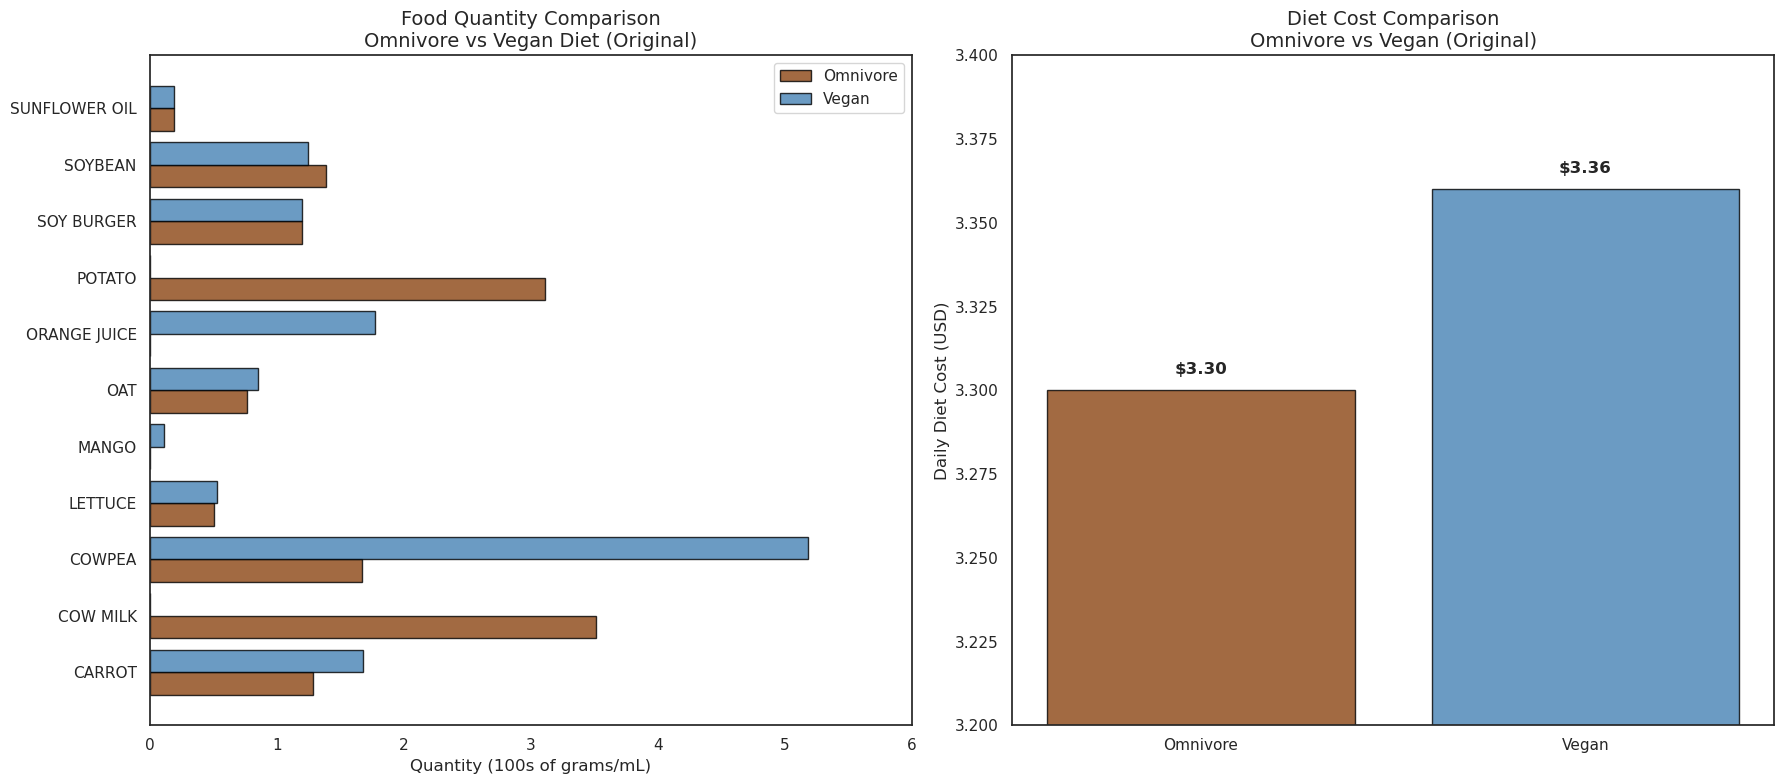

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set Seaborn style for better aesthetics with a clean background
sns.set_theme(style="white", palette="muted")

# Corrected data with all unique food items
foods = [
    "CARROT", "COW MILK", "COWPEA", "LETTUCE", "MANGO",
    "OAT", "ORANGE JUICE", "POTATO", "SOY BURGER", 
    "SOYBEAN", "SUNFLOWER OIL"
]

# Omnivore values (0 for foods not in diet)
omnivore_values = [
    1.285283,  # CARROT
    3.514002,  # COW MILK
    1.668872,  # COWPEA
    0.503611,  # LETTUCE
    0,          # MANGO (not in omnivore)
    0.763807,  # OAT
    0,          # ORANGE JUICE (not in omnivore)
    3.113865,  # POTATO
    1.194030,  # SOY BURGER
    1.389350,  # SOYBEAN
    0.189099   # SUNFLOWER OIL
]

# Vegan values (0 for foods not in diet)
vegan_values = [
    1.681498,  # CARROT
    0,          # COW MILK (not in vegan)
    5.183983,  # COWPEA
    0.529520,  # LETTUCE
    0.111007,  # MANGO
    0.848433,  # OAT
    1.773354,  # ORANGE JUICE
    0,          # POTATO (not in vegan)
    1.194030,  # SOY BURGER
    1.243387,  # SOYBEAN
    0.185898   # SUNFLOWER OIL
]

# Define cost values
omnivore_cost = 3.30
vegan_cost = 3.36

# Create figure and axes with a white background
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='w')

# Bar chart for omnivore and vegan diets
y = np.arange(len(foods))
bar_width = 0.4

# Brown for omnivore and blue for vegan
axes[0].barh(y - bar_width/2, omnivore_values, bar_width, color='#8B4513', alpha=0.8, edgecolor='black', label="Omnivore")
axes[0].barh(y + bar_width/2, vegan_values, bar_width, color='#4682B4', alpha=0.8, edgecolor='black', label="Vegan")

axes[0].set_yticks(y)
axes[0].set_yticklabels(foods)
axes[0].set_xlabel('Quantity (100s of grams/mL)', fontsize=12)
axes[0].set_title('Food Quantity Comparison\nOmnivore vs Vegan Diet (Original)', fontsize=14)
axes[0].set_xlim(0, 6)  # Adjusted to accommodate highest value (5.18)
axes[0].legend()

# Diet cost comparison
axes[1].bar(['Omnivore', 'Vegan'], [omnivore_cost, vegan_cost], color=['#8B4513', '#4682B4'], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Daily Diet Cost (USD)', fontsize=12)
axes[1].set_title('Diet Cost Comparison\nOmnivore vs Vegan (Original)', fontsize=14)
axes[1].set_ylim(3.20, 3.40)

# Annotate costs
for i, cost in enumerate([omnivore_cost, vegan_cost]):
    axes[1].text(i, cost + 0.005, f'${cost:.2f}', ha='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

### **[X]: Cost comparison: Co2 emissions**

In [42]:
#CO2 Omnivore
df['Price with Co2 Social Cost per 100g (USD)'] = (0.0185 * df['Carbon Footprint kg CO2eq/kg or l of food ITEM']) + df['Average Price per 100g (USD)']

price_cotwo_col = 'Price with Co2 Social Cost per 100g (USD)'
group = "F 19-30"
diet = 'not vegan'

solution = get_grub(group, diet, df, price_cotwo_col)


Cost of diet for F 19-30 with a(n) not vegan diet, controlling for C02 social cost is $3.47 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           4.931957
COW MILK         2.378574
COWPEA           2.406439
LETTUCE          0.061459
MANGO            0.655301
OAT              0.960015
SOY BURGER       1.194030
SOYBEAN          1.131157
SUNFLOWER OIL    0.155631
dtype: float64


In [43]:
#CO2 Vegan
df['Price with Co2 Social Cost per 100g (USD)'] = (0.0185 * df['Carbon Footprint kg CO2eq/kg or l of food ITEM']) + df['Average Price per 100g (USD)']

price_cotwo_col = 'Price with Co2 Social Cost per 100g (USD)'
group = "F 19-30"
diet = 'vegan'


solution = get_grub(group, diet, df, price_cotwo_col)


Cost of diet for F 19-30 with a(n) vegan diet, controlling for C02 social cost is $3.49 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           4.737367
COWPEA           2.232558
LETTUCE          0.073666
MANGO            0.759613
OAT              0.962603
ORANGE JUICE     2.212507
SOY BURGER       1.194030
SOYBEAN          1.197894
SUNFLOWER OIL    0.157119
dtype: float64


#### Description - The visualization compares the food quantities and daily diet costs for the Omnivore and Vegan diets while considering the CO2 social cost. On the left, the bar chart shows the quantities of various food items (in 100s of grams/mL) for both diets, with teal representing the omnivore diet and light coral representing the vegan diet. The omnivore diet contains larger portions of cow milk and cowpea, while the vegan diet emphasizes foods like carrots and oats. On the right, the diet costs for both the omnivore and vegan diets are shown as $3.47 and $3.49 per day, respectively, indicating a small difference in cost despite the varied food composition. This suggests that both diets have similar environmental costs when factoring in the CO2 emissions.

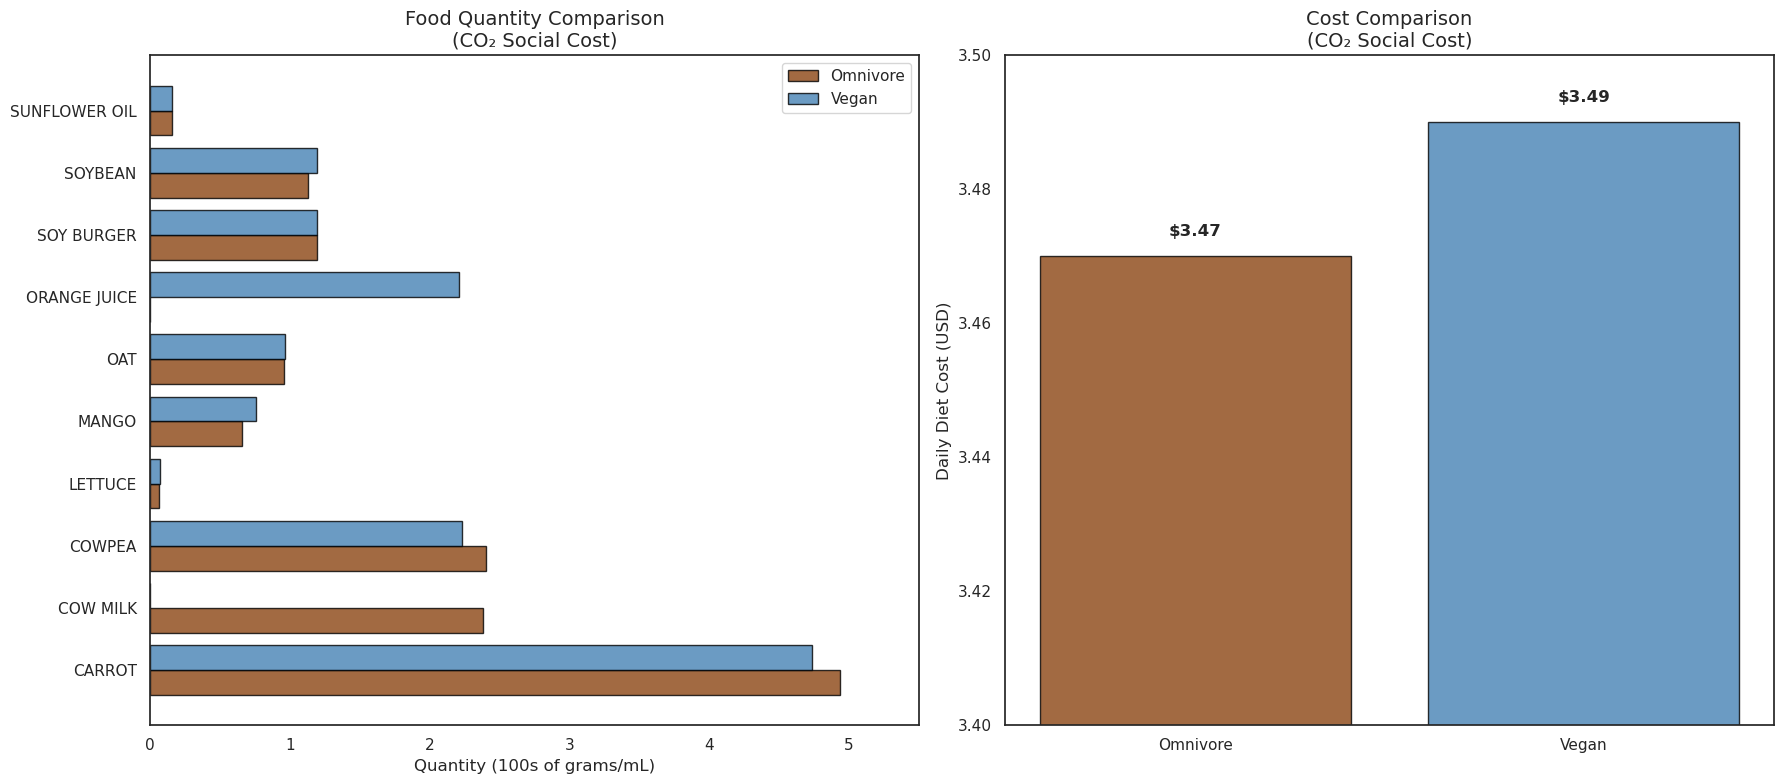

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set Seaborn style for better aesthetics with a clean background
sns.set_theme(style="white", palette="muted")

# Corrected data with all unique food items
foods = [
    "CARROT", "COW MILK", "COWPEA", "LETTUCE", "MANGO",
    "OAT", "ORANGE JUICE", "SOY BURGER", "SOYBEAN", "SUNFLOWER OIL"
]

# Omnivore values (0 for foods not in diet)
omnivore_values = [
    4.931957,  # CARROT
    2.378574,  # COW MILK
    2.406439,  # COWPEA
    0.061459,  # LETTUCE
    0.655301,  # MANGO
    0.960015,  # OAT
    0,          # ORANGE JUICE (not in omnivore)
    1.194030,  # SOY BURGER
    1.131157,  # SOYBEAN
    0.155631   # SUNFLOWER OIL
]

# Vegan values (0 for foods not in diet)
vegan_values = [
    4.737367,  # CARROT
    0,         # COW MILK (not in vegan)
    2.232558,  # COWPEA
    0.073666,  # LETTUCE
    0.759613,  # MANGO
    0.962603,  # OAT
    2.212507,  # ORANGE JUICE
    1.194030,  # SOY BURGER
    1.197894,  # SOYBEAN
    0.157119   # SUNFLOWER OIL
]

# Define cost values with CO2 social cost considered
omnivore_cost = 3.47
vegan_cost = 3.49

# Create figure and axes with a white background
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='w')

# Bar chart for omnivore and vegan diets
y = np.arange(len(foods))
bar_width = 0.4

# Brown for omnivore and blue for vegan
axes[0].barh(y - bar_width/2, omnivore_values, bar_width, 
            color='#8B4513', alpha=0.8, edgecolor='black', label="Omnivore")
axes[0].barh(y + bar_width/2, vegan_values, bar_width, 
            color='#4682B4', alpha=0.8, edgecolor='black', label="Vegan")

axes[0].set_yticks(y)
axes[0].set_yticklabels(foods)
axes[0].set_xlabel('Quantity (100s of grams/mL)', fontsize=12)
axes[0].set_title('Food Quantity Comparison\n(CO₂ Social Cost)', fontsize=14)
axes[0].set_xlim(0, 5.5)  # Accommodate largest value (4.93)
axes[0].legend()

# Diet cost comparison
axes[1].bar(['Omnivore', 'Vegan'], [omnivore_cost, vegan_cost], 
           color=['#8B4513', '#4682B4'], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Daily Diet Cost (USD)', fontsize=12)
axes[1].set_title('Cost Comparison\n(CO₂ Social Cost)', fontsize=14)
axes[1].set_ylim(3.40, 3.50)

# Annotate costs
for i, cost in enumerate([omnivore_cost, vegan_cost]):
    axes[1].text(i, cost + 0.003, f'${cost:.2f}', 
                ha='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

### **[X]: Cost comparison: H20 Footprint**

In [45]:
#Water Omnivore
water_col = 'Water Footprint liters water/kg o liter of food ITEM'
group = "F 19-30"
diet = 'not vegan'


solution = get_grub(group, diet, df, water_col)


Cost of diet for F 19-30 with a(n) not vegan diet, controlling for Water footprint is $11.85 per day.

You'll be eating (in 100s of grams or milliliters):
BLACKBERRY        0.255939
CARROT            7.389950
CURRANT           1.676870
EGGPLANT          0.482490
SOY BURGER        0.040215
SUNFLOWER OIL     0.037028
TOMATO & BASIL    7.415913
dtype: float64


In [46]:
#Water vegan
water_col = 'Water Footprint liters water/kg o liter of food ITEM'
group = "F 19-30"
diet = 'vegan'


solution = get_grub(group, diet, df, water_col)

Cost of diet for F 19-30 with a(n) vegan diet, controlling for Water footprint is $11.85 per day.

You'll be eating (in 100s of grams or milliliters):
BLACKBERRY        0.255939
CARROT            7.389950
CURRANT           1.676870
EGGPLANT          0.482490
SOY BURGER        0.040215
SUNFLOWER OIL     0.037028
TOMATO & BASIL    7.415913
dtype: float64


#### Description - The visualization compares the Omnivore and Vegan diets, focusing on the water footprint. On the left, the bar chart illustrates the quantity of various foods (in 100s of grams/mL) for both diets, with green representing the omnivore diet and orange representing the vegan diet. The food quantities are quite similar between the two diets, with slight differences in items like carrots and currants. On the right, the daily diet costs for both diets are shown, each costing $11.85 per day when considering the water footprint, indicating that both diets have an equal environmental water impact. This visualization highlights the comparable cost and water usage of both diets.

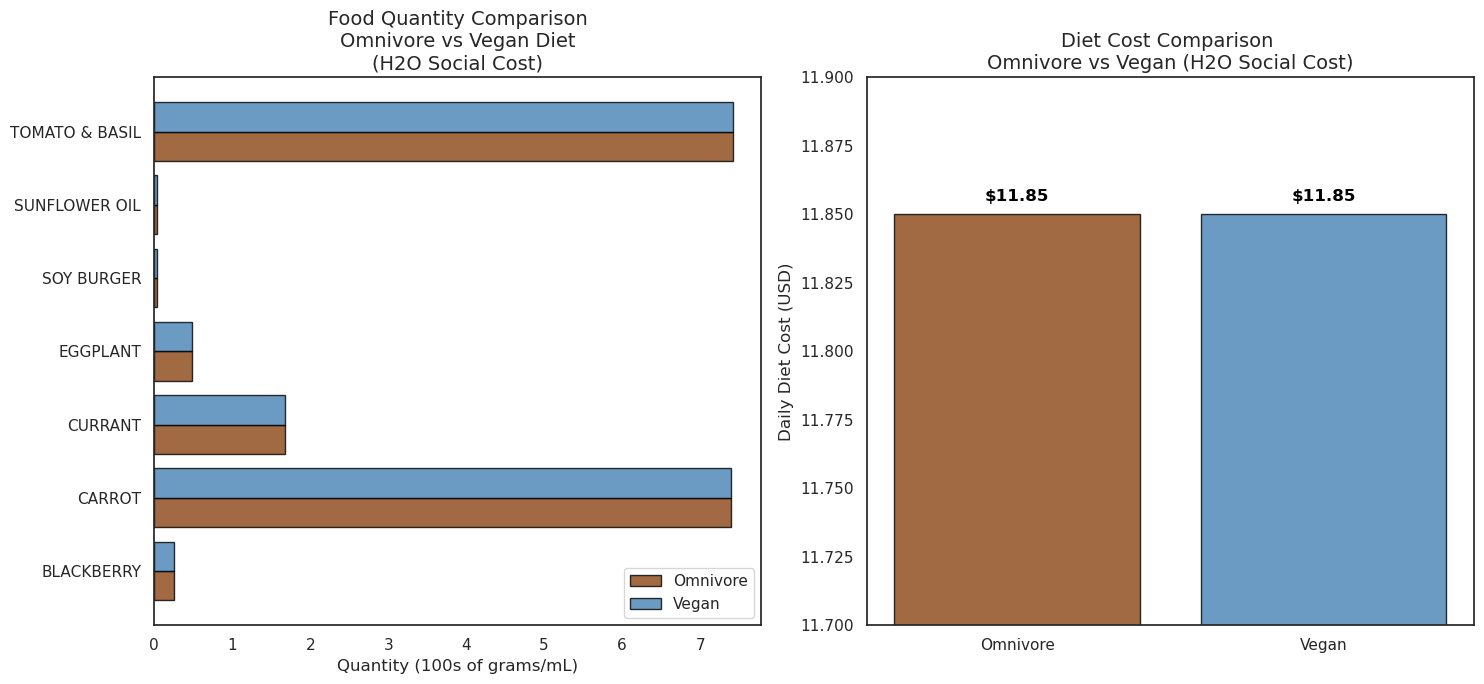

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set Seaborn style for better aesthetics with a clean background
sns.set_theme(style="white", palette="muted")

# Updated data for omnivore and vegan diet with water footprint
foods = ["BLACKBERRY", "CARROT", "CURRANT", "EGGPLANT", "SOY BURGER", 
         "SUNFLOWER OIL", "TOMATO & BASIL"]

# Updated values for omnivore diet (in 100s of grams or milliliters)
omnivore_values = [0.255939, 7.389950, 1.676870, 0.482490, 0.040215, 
                   0.037028, 7.415913]

# Updated values for vegan diet (in 100s of grams or milliliters)
vegan_values = [0.255939, 7.389950, 1.676870, 0.482490, 0.040215, 
                0.037028, 7.415913]

# Define cost values with H2O social cost considered
omnivore_cost_h2o = 11.85  # Updated based on H2O social cost
vegan_cost_h2o = 11.85  # Updated based on H2O social cost

# Create figure and axes with a white background
fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor='w')

# Bar chart for omnivore and vegan diets with brown and blue colors
y = np.arange(len(foods))
bar_width = 0.4

# Brown for omnivore and blue for vegan
axes[0].barh(y - bar_width/2, omnivore_values, bar_width, color='#8B4513', alpha=0.8, edgecolor='black', label="Omnivore")  # Brown
axes[0].barh(y + bar_width/2, vegan_values, bar_width, color='#4682B4', alpha=0.8, edgecolor='black', label="Vegan")  # Blue

axes[0].set_yticks(y)
axes[0].set_yticklabels(foods)
axes[0].set_xlabel('Quantity (100s of grams/mL)', fontsize=12)
axes[0].set_title('Food Quantity Comparison\nOmnivore vs Vegan Diet\n(H2O Social Cost)', fontsize=14)
axes[0].legend()

# Plot diet cost comparison for omnivore and vegan
axes[1].bar(['Omnivore', 'Vegan'], [omnivore_cost_h2o, vegan_cost_h2o], color=['#8B4513', '#4682B4'], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Daily Diet Cost (USD)', fontsize=12)
axes[1].set_title('Diet Cost Comparison \nOmnivore vs Vegan (H2O Social Cost)', fontsize=14)

# Adjust the y-axis to make the difference more obvious
axes[1].set_ylim(11.70, 11.90)

# Annotate the cost values
for i, cost in enumerate([omnivore_cost_h2o, vegan_cost_h2o]):
    axes[1].text(i, cost + 0.005, f'${cost:.2f}', ha='center', fontsize=12, weight='bold', color='black')

# Apply a tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

In [48]:
import pandas as pd

# All unique food items
foods = [
    "BLACKBERRY", "CARROT", "COW MILK", "COWPEA", "CURRANT",
    "EGGPLANT", "LETTUCE", "MANGO", "OAT", "ORANGE JUICE",
    "POTATO", "SOY BURGER", "SOYBEAN", "SUNFLOWER OIL", "TOMATO & BASIL"
]

# Create DataFrame with all foods
food_df = pd.DataFrame(index=foods)

# Add diet scenarios
food_df['original_om'] = [
    0.000000, 1.285283, 3.514002, 1.668872, 0.000000,
    0.000000, 0.503611, 0.000000, 0.763807, 0.000000,
    3.113865, 1.194030, 1.389350, 0.189099, 0.000000
]

food_df['original_vegan'] = [
    0.000000, 1.681498, 0.000000, 5.183983, 0.000000,
    0.000000, 0.529520, 0.111007, 0.848433, 1.773354,
    0.000000, 1.194030, 1.243387, 0.185898, 0.000000
]

food_df['co2_om'] = [
    0.000000, 4.931957, 2.378574, 2.406439, 0.000000,
    0.000000, 0.061459, 0.655301, 0.960015, 0.000000,
    0.000000, 1.194030, 1.131157, 0.155631, 0.000000
]

food_df['co2_vegan'] = [
    0.000000, 4.737367, 0.000000, 2.232558, 0.000000,
    0.000000, 0.073666, 0.759613, 0.962603, 2.212507,
    0.000000, 1.194030, 1.197894, 0.157119, 0.000000
]

food_df['h2o_om'] = [
    0.255939, 7.389950, 0.000000, 0.000000, 1.676870,
    0.482490, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.040215, 0.000000, 0.037028, 7.415913
]

food_df['h2o_vegan'] = [
    0.255939, 7.389950, 0.000000, 0.000000, 1.676870,
    0.482490, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.040215, 0.000000, 0.037028, 7.415913
]

print("Food Quantity DataFrame:")
food_df

Food Quantity DataFrame:


,original_om,original_vegan,co2_om,co2_vegan,h2o_om,h2o_vegan
BLACKBERRY,0.000000,0.000000,0.000000,0.000000,0.255939,0.255939
CARROT,1.285283,1.681498,4.931957,4.737367,7.389950,7.389950
COW MILK,3.514002,0.000000,2.378574,0.000000,0.000000,0.000000
COWPEA,1.668872,5.183983,2.406439,2.232558,0.000000,0.000000
CURRANT,0.000000,0.000000,0.000000,0.000000,1.676870,1.676870
EGGPLANT,0.000000,0.000000,0.000000,0.000000,0.482490,0.482490
LETTUCE,0.503611,0.529520,0.061459,0.073666,0.000000,0.000000
MANGO,0.000000,0.111007,0.655301,0.759613,0.000000,0.000000
OAT,0.763807,0.848433,0.960015,0.962603,0.000000,0.000000
ORANGE JUICE,0.000000,1.773354,0.000000,2.212507,0.000000,0.000000


#### Description - The visualization contrasts vegan and omnivore dietary compositions across Original, CO₂-adjusted, and H₂O-adjusted scenarios, revealing how environmental priorities reshape food choices. Key insights show CO₂ optimization drives increased vegetable consumption (e.g., carrots surge 4x in omnivore diets) and reduced animal products, while H₂O constraints impose identical, radical shifts for both diets—prioritizing water-efficient foods like tomatoes/basil (7.4x) and eliminating grains/dairy. Original diets maintain conventional patterns (omnivore dairy, vegan legumes), but costs spike 359% under H₂O scenarios, underscoring the economic toll of water conservation compared to modest CO₂ adjustments (+5-7%). The plots highlight trade-offs between sustainability goals, dietary flexibility, and affordability.

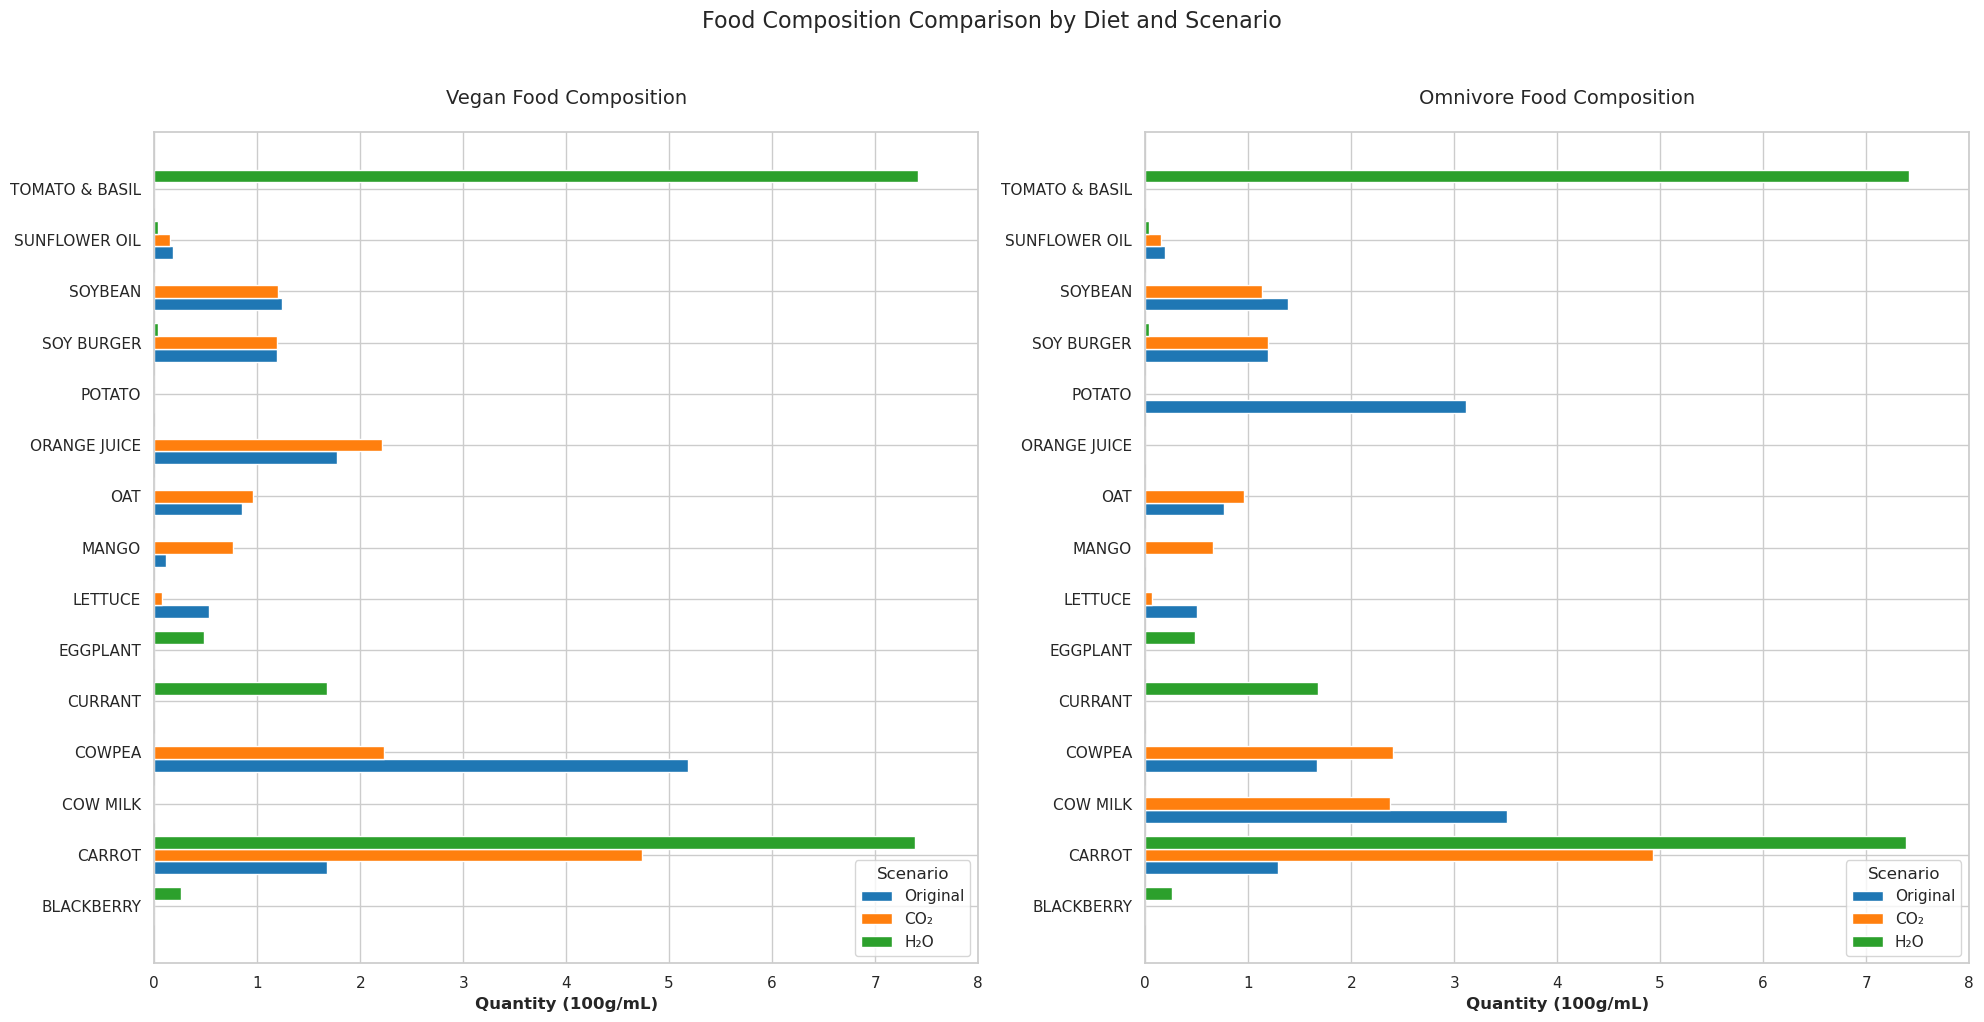

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
scenario_colors = {'Original': '#1f77b4', 'CO₂': '#ff7f0e', 'H₂O': '#2ca02c'}

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# =====================
# 1. Vegan Composition
# =====================
vegan_data = food_df[['original_vegan', 'co2_vegan', 'h2o_vegan']]
vegan_data.columns = ['Original', 'CO₂', 'H₂O']

y = np.arange(len(foods))
bar_height = 0.25

for i, scenario in enumerate(['Original', 'CO₂', 'H₂O']):
    ax1.barh(y + i*bar_height, vegan_data[scenario], bar_height,
            color=scenario_colors[scenario], label=scenario)

ax1.set_yticks(y + bar_height)
ax1.set_yticklabels(foods)
ax1.set_xlabel('Quantity (100g/mL)', fontweight='bold')
ax1.set_title('Vegan Food Composition', pad=20, fontsize=14)
ax1.legend(title='Scenario')
ax1.set_xlim(0, 8)

# =====================
# 2. Omnivore Composition
# =====================
omni_data = food_df[['original_om', 'co2_om', 'h2o_om']]
omni_data.columns = ['Original', 'CO₂', 'H₂O']

for i, scenario in enumerate(['Original', 'CO₂', 'H₂O']):
    ax2.barh(y + i*bar_height, omni_data[scenario], bar_height,
            color=scenario_colors[scenario], label=scenario)

ax2.set_yticks(y + bar_height)
ax2.set_yticklabels(foods)
ax2.set_xlabel('Quantity (100g/mL)', fontweight='bold')
ax2.set_title('Omnivore Food Composition', pad=20, fontsize=14)
ax2.legend(title='Scenario')
ax2.set_xlim(0, 8)

# Add main title
plt.suptitle('Food Composition Comparison by Diet and Scenario', y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

In [91]:
import pandas as pd

cost_data = {
    'Original': [3.30, 3.36],
    'CO₂': [3.47, 3.49],
    'H₂O': [11.85, 11.85]
}

cost_df = pd.DataFrame(cost_data, index=['Omnivore', 'Vegan'])
cost_df.columns.name = 'Scenario'
cost_df.index.name = 'Diet'
cost_df

Scenario,Original,CO₂,H₂O
Diet,,,
Omnivore,3.30,3.47,11.85
Vegan,3.36,3.49,11.85


#### Description - The plot comparing the daily diet costs across different scenarios (Original, CO2, and H2O) clearly shows that the H2O cost is significantly higher than both the Original and CO2 cost for both omnivore and vegan diets. The H2O cost for both diets is $11.85, while the Original and CO2 costs are much lower, with omnivore diets at $3.30 and $3.47, and vegan diets at $3.36 and $3.49, respectively. This highlights the substantial impact of water footprint on the diet cost, compared to CO2 emissions.

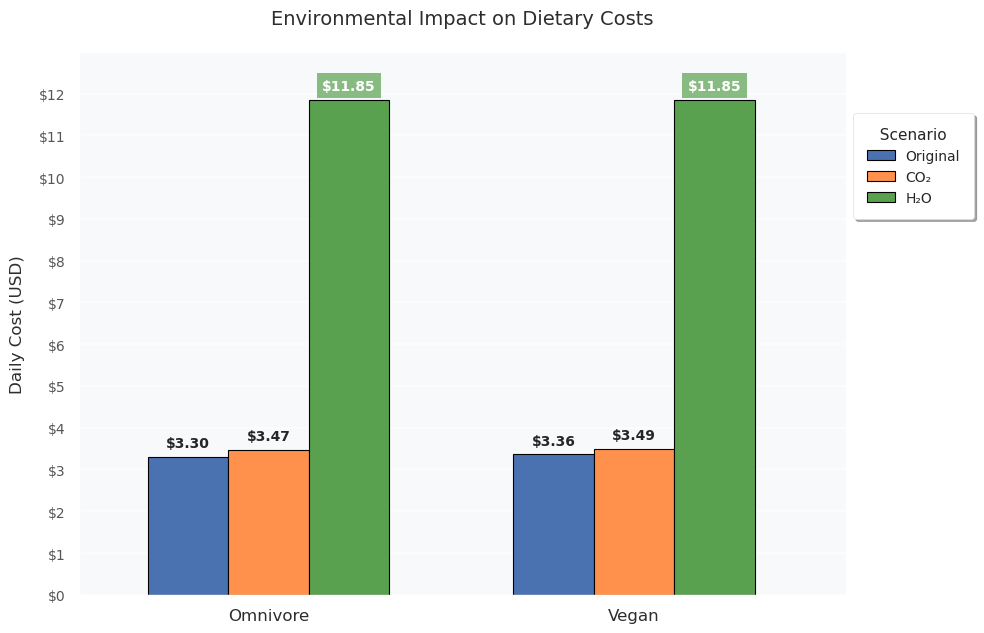

In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create DataFrame with diet costs
cost_data = {
    'Original': [3.30, 3.36],
    'CO₂': [3.47, 3.49],
    'H₂O': [11.85, 11.85]
}
cost_df = pd.DataFrame(cost_data, index=['Omnivore', 'Vegan'])

# Visualization settings
colors = {'Original': '#4B72B0', 'CO₂': '#FF914D', 'H₂O': '#59A14F'}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6.5))

# Set background colors
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')  # Light gray background

bar_width = 0.22
x = np.arange(len(cost_df.index))

# Create bars without hatch patterns
for i, scenario in enumerate(cost_df.columns):
    ax.bar(x + i * bar_width, cost_df[scenario], bar_width,
          label=scenario, color=colors[scenario],
          edgecolor='black', linewidth=0.8,
          zorder=2)

# Grid customization
ax.grid(axis='y', color='white', linestyle='-', linewidth=1.2, zorder=0)
ax.grid(axis='x', visible=False)

# Axis formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(cost_df.index, fontsize=12, color='#2D2D2D')
ax.set_yticks(np.arange(0, 13, 1))
ax.set_yticklabels([f'${x}' for x in range(13)], fontsize=10, color='#555555')
ax.set_ylabel('Daily Cost (USD)', fontsize=12, color='#2D2D2D', labelpad=10)
ax.set_title('Environmental Impact on Dietary Costs',  # No bold
           fontsize=14, pad=20, color='#2D2D2D')

# Value labels with clear H₂O display
for container in ax.containers:
    labels = ax.bar_label(container, fmt='$%.2f', padding=5,
                         fontsize=10, fontweight='bold')
    # Highlight H₂O labels
    for label, bar in zip(labels, container):
        if bar.get_height() > 10:
            label.set_color('white')
            label.set_bbox(dict(facecolor=colors['H₂O'], alpha=0.7, edgecolor='none'))

# Legend customization
legend = ax.legend(title='  Scenario  ', frameon=True, shadow=True,
                  borderpad=1, title_fontsize=11, fontsize=10,
                  bbox_to_anchor=(1, 0.9), facecolor='white')
legend.get_frame().set_edgecolor('#DDDDDD')

# Final adjustments
plt.ylim(0, 13)
plt.xlim(-0.3, 1.8)
plt.tight_layout()
plt.show()

### **[X]: Cost comparison: Original Model (min diet cost) for different groups**

In [75]:
# The minimum cost below is calculated using the formula updated as recently as 03/07/25

from scipy.optimize import linprog as lp
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

def get_grub(sex_age_group, diet, df):
    if (diet == 'vegan') or (diet == 'plant-based'):
        df = df[df['animal product'] == 'plant-based']
    D = {}
    count = 0
    
    for food in df.index:
        try:
            FDC = df.loc[df.index == food, 'FDC ID'].iloc[0]
            count += 1
            D[food] = fdc.nutrients(apikey, FDC).Quantity
        except AttributeError:
            warnings.warn(f"Couldn't find FDC Code {FDC} for food {food}.")
    
    D = pd.DataFrame(D, dtype=float)
    df.dropna(how='any', inplace=True)

    Prices = df.groupby('Food')['Average Price per 100g (USD)'].min()
    p = Prices.apply(lambda x: x).dropna()
    
    use = p.index.intersection(D.columns)
    p = p[use]
    tol = 1e-6

    Aall = D[p.index].fillna(0)

    Amin = Aall.loc[bmin.index]
    Amax = Aall.loc[bmax.index]
    
    A = pd.concat([Amin, -Amax])
    
    result = lp(p, -A, -b[sex_age_group], method='highs')
    print(f"Cost of diet for {sex_age_group} is ${result.fun:.2f} per day.")
    
    diet = pd.Series(result.x, index=p.index)
    
    print("\nYou'll be eating (in 100s of grams or milliliters):")
    print(diet[diet >= tol])
    
    return result.fun

groups = [
    "C 1-3", "F 4-8", "M 4-8", "F 9-13", "M 9-13", 
    "F 14-18", "M 14-18", "F 19-30", "M 19-30", 
    "F 31-50", "M 31-50", "F 51+", "M 51+"
]

results_df = pd.DataFrame(columns=['Group', 'Minimum Cost ($)'])

for group in groups:
    cost = get_grub(group, diet, df)
    results_df = pd.concat([results_df, pd.DataFrame({'Group': [group], 'Minimum Cost ($)': [cost]})], ignore_index=True)

results_df

Cost of diet for C 1-3 is $1.74 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           0.491048
COW MILK         3.537273
LETTUCE          0.042169
MANGO            1.095130
POTATO           0.993532
SORGHUM          0.518216
SOY BURGER       0.447761
SOYBEAN          0.925056
SUNFLOWER OIL    0.072598
dtype: float64
Cost of diet for F 4-8 is $2.33 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           0.460683
COW MILK         5.154131
LETTUCE          0.160142
MANGO            0.309191
OAT              0.314900
POTATO           2.794873
SOY BURGER       0.597015
SOYBEAN          1.608523
SUNFLOWER OIL    0.084792
dtype: float64
Cost of diet for M 4-8 is $2.33 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           0.460683
COW MILK         5.154131
LETTUCE          0.160142
MANGO            0.309191
OAT              0.314900
POTATO           2.794873
SOY BURGER       0.597015
SOYBEAN          1.608523
SUNFLOWER OI

,Group,Minimum Cost ($)
0,C 1-3,1.742005
1,F 4-8,2.327771
2,M 4-8,2.327771
3,F 9-13,3.069409
4,M 9-13,3.053172
5,F 14-18,3.406737
6,M 14-18,3.509138
7,F 19-30,3.297150
8,M 19-30,3.422043
9,F 31-50,3.297150


#### Description - The bar chart displays the minimum diet cost for different age groups and genders. The chart reveals that for most age groups, the minimum diet cost for females and males is quite similar, with only slight variations across the categories. Children (1-3 years old) have a notably lower diet cost compared to older age groups. As age increases, the diet cost tends to rise, peaking for the 14-18 age group. The cost for males and females in the same age groups is generally close, though there are minor differences in some categories. This highlights the variation in dietary costs across both gender and age.

<Figure size 1000x600 with 0 Axes>

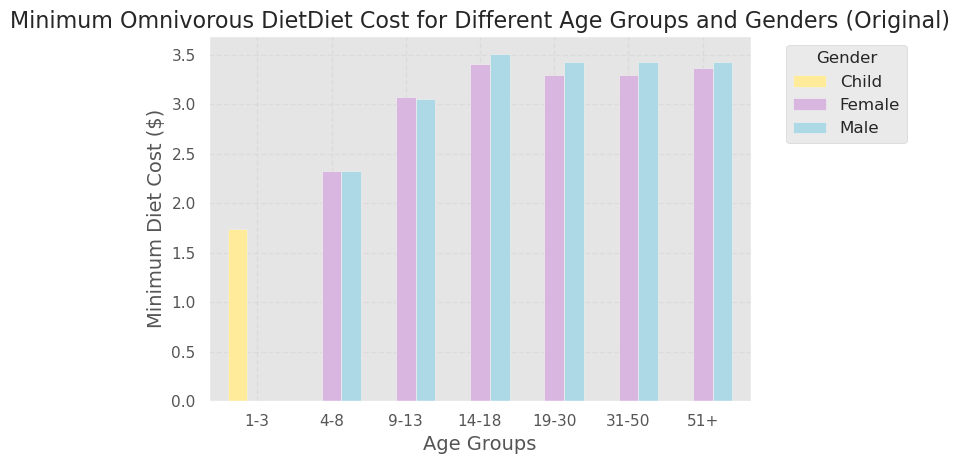

In [81]:
# static plot - Minimum Diet Cost for Different Age Groups and Genders

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = {
    'Age': ['1-3', '4-8', '4-8', '9-13', '9-13', '14-18', '14-18', '19-30', '19-30', '31-50', '31-50', '51+', '51+'],
    'Gender': ['C', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Minimum Cost ($)': [1.742005, 2.327771, 2.327771, 3.069409, 3.053172, 3.406737, 3.509138, 3.297150, 3.422043, 3.297150, 3.422043, 3.363272, 3.422043]
}

df_results = pd.DataFrame(data)

age_order = ["1-3", "4-8", "9-13", "14-18", "19-30", "31-50", "51+"]

df_results['Age'] = pd.Categorical(df_results['Age'], categories=age_order, ordered=True)

df_results_pivot = df_results.pivot(index='Age', columns='Gender', values='Minimum Cost ($)')

plt.figure(figsize=(10, 6))

df_results_pivot.plot(kind='bar', stacked=False, color=['#FFEB99', '#D8B6E0', '#ADD8E6'], width=0.8)

plt.title('Minimum Omnivorous DietDiet Cost for Different Age Groups and Genders (Original)', fontsize=16)
plt.xlabel('Age Groups', fontsize=14)
plt.ylabel('Minimum Diet Cost ($)', fontsize=14)

plt.xticks(rotation=0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1.05, 1), labels=['Child', 'Female', 'Male'], fontsize=12)
plt.show()

In [80]:
# non-static plot - Minimum Diet Cost for Different Age Groups and Genders

import plotly.express as px
import pandas as pd
import numpy as np

data = {
    'Age': ['1-3', '4-8', '4-8', '9-13', '9-13', '14-18', '14-18', '19-30', '19-30', '31-50', '31-50', '51+', '51+'],
    'Gender': ['C', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Minimum Cost ($)': [1.742005, 2.327771, 2.327771, 3.069409, 3.053172, 3.406737, 3.509138, 3.297150, 3.422043, 3.297150, 3.422043, 3.363272, 3.422043]
}

df_results = pd.DataFrame(data)

fig = px.bar(df_results, x="Age", y="Minimum Cost ($)", color="Gender", 
             title="Minimum Omnivorous Diet Cost for Different Age Groups and Genders (Original)",
             labels={"Minimum Cost ($)": "Minimum Diet Cost ($)", "Age": "Age Groups"},
             color_discrete_map={"C": '#FFEB99', "F": "#D8A7CB", "M": "#A7D8EB"}) 

fig.update_layout(
    barmode='group',
    xaxis_tickangle=0,
    title_x=0.5,
    title_font=dict(size=20, family='Verdana'),
    xaxis_title_font=dict(size=14, family='Verdana'),
    yaxis_title_font=dict(size=14, family='Verdana'),
    legend_title=dict(text='Gender', font=dict(size=14)),
    legend=dict(title_font=dict(size=14)),
    plot_bgcolor='whitesmoke',  
    paper_bgcolor='whitesmoke'  
)

fig.show()

### **[B]: Is your solution edible?**

Yes, our solution is edible! Here is our recipe:

**Potato Sliders:**

> Prepare the Potato Buns: <br>

>> Slice the potatoes into even, bun-sized rounds (about ½-inch thick). <br>
>> Heat the oil in a skillet over medium heat. Fry the potato slices until golden brown and crispy, about 3-4 minutes per side. Remove and drain on paper towels. <br>

> Prepare the Vegetables: <br>

>> Thinly slice the carrot into small rectangles. <br>
>>Wash and chop the lettuce into smaller pieces. <br>
>> Boil the peas until tender, then set aside for garnish. <br>

> Cook the Burger Patties: <br>

>> In the same skillet, cook the burger patties over medium-high heat until fully cooked, about 3-4 minutes per side, depending on thickness. <br>

> Assemble the Sliders: <br>

>> Place a fried potato slice as the bottom "bun." <br>
>>Add a cooked burger patty. <br>
>> Layer with lettuce and carrot slices. <br>
>> Top with another fried potato slice as the "bun." <br>
>> Garnish with boiled peas on top or around the plate <br>

### **[B]: What is total cost for population of interest?**

**Population function:**

In [52]:
countries = wbdata.get_countries()
country_dict = {}

for country in countries:
    country_code = country['id']
    country_name = country['name']
    country_dict[country_name] = country_code

def int_to_str(num):
    if 0 <= num < 10:
        return f"0{num}"
    else:
        return str(num)

def population_range(year, sex, age_range, place):
    sex_codes = {"people": "", "females": "FE", "males": "MA"}
    sex_used = sex_codes[sex]
    lower, upper = int_to_str(age_range[0]), int_to_str(age_range[1])
    range_string = lower + upper
    country_code = country_dict.get(place)
    df = wbdata.get_dataframe({"SP.POP." + range_string + "." + sex_used: "Population"},
                              country= {country_code: place}).squeeze()
    df = df.to_frame().reset_index()
    population_total = int(df[df["date"] == str(year)]["Population"].iloc[0])
    return population_total

def over_80_pop(year, sex, place):
    sex_codes = {"people": "", "females": "FE", "males": "MA"}
    sex_used = sex_codes[sex]
    country_code = country_dict.get(place)

    df = wbdata.get_dataframe({"SP.POP." + "80UP" + "." + sex_used: "Population"},
                              country= {country_code: place}).squeeze()
    df = df.to_frame().reset_index()
    population_total = int(df[df["date"] == str(year)]["Population"].iloc[0])
    return population_total

def dict_helper(year, sex, age_range, place):
    if len(age_range) == 1:
        age_range = [age_range[0], age_range[0]]
    elif age_range[1] < age_range[0]:
      raise ValueError(f"Please ensure that the second value in the range is greater than the first.")

    minimum_age, maximum_age = age_range
    possible_minimums = [i for i in range(0, 76, 5)]
    possible_maximums = [i for i in range(4, 80, 5)]

    my_dict = {}
    for age in range(minimum_age, maximum_age + 1):
        range_index = next((i for i, min_val in enumerate(possible_minimums) if
                            min_val <= age and age <= possible_maximums[i]), None)
        if range_index is not None:
            popl_value = population_range(year, sex, [possible_minimums[range_index], possible_maximums[range_index]], place) // 5
            my_dict[age] = popl_value
        elif age >= 80 and age <= 100:
            my_dict[age] = over_80_pop(year, sex, place) / 20
        else:
            raise ValueError(f"No age range available for age {age}")
    return my_dict

def population(year, sex = "all", age_range = [0,100], place = "World"):
    if place not in country_dict:
        valid_regions = ", ".join(country_dict.keys())
        raise ValueError(f"The region '{place}' is not valid. Please choose from the following regions: {valid_regions}")
    if sex in ["all", "people", "p", "P", "People", "All", "Everyone"]:
      female_dict = dict_helper(year, "females", age_range, place)
      male_dict = dict_helper(year, "males", age_range, place)
      return sum(female_dict.values()) + sum(male_dict.values())
    elif sex in ["female", "females", "f", "Female", "Females", "F", "FE"]:
      female_dict = dict_helper(year, "females", age_range, place)
      return sum(female_dict.values())
    elif sex in ["male", "males", "m", "Male", "Males", "M", "MA"]:
      male_dict = dict_helper(year, "males", age_range, place)
      return sum(male_dict.values())

**Dataframe:**

In [53]:
def create_population_dataframe(regions, years, age_range):
    data = []

    if len(age_range) == 1:
        full_age_range = [age_range[0]]
    else:
        full_age_range = list(range(age_range[0], age_range[1] + 1))

    for region in regions:
        for year in years:
            row = {'Region': region, 'Year': year}
            for age in full_age_range:
                male_population = population(year, 'male', [age], region)
                female_population = population(year, 'female', [age], region)

                row[f'Male Population Age {age}'] = male_population
                row[f'Female Population Age {age}'] = female_population
            data.append(row)

    df = pd.DataFrame(data)
    df.set_index(['Region', 'Year'], inplace=True)
    return df

In [54]:
usa_pop_df = create_population_dataframe(["United States"], [2023], [0, 80])

groupings = {
    "C 1-3": [
        "Male Population Age 1", "Male Population Age 2", "Male Population Age 3",
        "Female Population Age 1", "Female Population Age 2", "Female Population Age 3"
    ],
    "F 4-8": [
        "Female Population Age 4", "Female Population Age 5", "Female Population Age 6",
        "Female Population Age 7", "Female Population Age 8"
    ],
    "M 4-8": [
        "Male Population Age 4", "Male Population Age 5", "Male Population Age 6",
        "Male Population Age 7", "Male Population Age 8"
    ],
    "F 9-13": [
        "Female Population Age 9", "Female Population Age 10", "Female Population Age 11",
        "Female Population Age 12", "Female Population Age 13"
    ],
    "M 9-13": [
        "Male Population Age 9", "Male Population Age 10", "Male Population Age 11",
        "Male Population Age 12", "Male Population Age 13"
    ],
    "F 14-18": [
        "Female Population Age 14", "Female Population Age 15", "Female Population Age 16",
        "Female Population Age 17", "Female Population Age 18"
    ],
    "M 14-18": [
        "Male Population Age 14", "Male Population Age 15", "Male Population Age 16",
        "Male Population Age 17", "Male Population Age 18"
    ],
    "F 19-30": [
        "Female Population Age 19", "Female Population Age 20", "Female Population Age 21",
        "Female Population Age 22", "Female Population Age 23", "Female Population Age 24",
        "Female Population Age 25", "Female Population Age 26", "Female Population Age 27",
        "Female Population Age 28", "Female Population Age 29", "Female Population Age 30"
    ],
    "M 19-30": [
        "Male Population Age 19", "Male Population Age 20", "Male Population Age 21",
        "Male Population Age 22", "Male Population Age 23", "Male Population Age 24",
        "Male Population Age 25", "Male Population Age 26", "Male Population Age 27",
        "Male Population Age 28", "Male Population Age 29", "Male Population Age 30"
    ],
    "F 31-50": [
        "Female Population Age 31", "Female Population Age 32", "Female Population Age 33",
        "Female Population Age 34", "Female Population Age 35", "Female Population Age 36",
        "Female Population Age 37", "Female Population Age 38", "Female Population Age 39",
        "Female Population Age 40", "Female Population Age 41", "Female Population Age 42",
        "Female Population Age 43", "Female Population Age 44", "Female Population Age 45",
        "Female Population Age 46", "Female Population Age 47", "Female Population Age 48",
        "Female Population Age 49", "Female Population Age 50"
    ],
    "M 31-50": [
        "Male Population Age 31", "Male Population Age 32", "Male Population Age 33",
        "Male Population Age 34", "Male Population Age 35", "Male Population Age 36",
        "Male Population Age 37", "Male Population Age 38", "Male Population Age 39",
        "Male Population Age 40", "Male Population Age 41", "Male Population Age 42",
        "Male Population Age 43", "Male Population Age 44", "Male Population Age 45",
        "Male Population Age 46", "Male Population Age 47", "Male Population Age 48",
        "Male Population Age 49", "Male Population Age 50"
    ],
    "F 51+": [
        "Female Population Age 51", "Female Population Age 52", "Female Population Age 53",
        "Female Population Age 54", "Female Population Age 55", "Female Population Age 56",
        "Female Population Age 57", "Female Population Age 58", "Female Population Age 59",
        "Female Population Age 60", "Female Population Age 61", "Female Population Age 62",
        "Female Population Age 63", "Female Population Age 64", "Female Population Age 65",
        "Female Population Age 66", "Female Population Age 67", "Female Population Age 68",
        "Female Population Age 69", "Female Population Age 70", "Female Population Age 71",
        "Female Population Age 72", "Female Population Age 73", "Female Population Age 74",
        "Female Population Age 75", "Female Population Age 76", "Female Population Age 77",
        "Female Population Age 78", "Female Population Age 79", "Female Population Age 80"
    ],
    "M 51+": [
        "Male Population Age 51", "Male Population Age 52", "Male Population Age 53",
        "Male Population Age 54", "Male Population Age 55", "Male Population Age 56",
        "Male Population Age 57", "Male Population Age 58", "Male Population Age 59",
        "Male Population Age 60", "Male Population Age 61", "Male Population Age 62",
        "Male Population Age 63", "Male Population Age 64", "Male Population Age 65",
        "Male Population Age 66", "Male Population Age 67", "Male Population Age 68",
        "Male Population Age 69", "Male Population Age 70", "Male Population Age 71",
        "Male Population Age 72", "Male Population Age 73", "Male Population Age 74",
        "Male Population Age 75", "Male Population Age 76", "Male Population Age 77",
        "Male Population Age 78", "Male Population Age 79", "Male Population Age 80"
    ]
}

# Loop through each group and sum the relevant columns
for group, cols in groupings.items():
    usa_pop_df[group] = usa_pop_df[cols].sum(axis=1)

# After summing the populations, drop the original age columns
columns_to_drop = [col for sublist in groupings.values() for col in sublist]
usa_pop_df.drop(columns=columns_to_drop, inplace=True)
usa_pop_df

,,Male Population Age 0,Female Population Age 0,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
Region,Year,,,,,,,,,,,,,,,
United States,2023,1859555,1776227,10907346,9500935,9992427,10058653,10646674,10579645,11242472,25700622,27479410,43051959,45568239,53186441.55,50890359.2


**Total Cost Function:**

Parameter can be `price`, `co2`, or `water`. Must run *Cost Comparison* cells before runnning this function.

In [55]:
def total_cost_pop(group, diet, df, parameter='price'):
    
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    
    try:
        # Select the appropriate calculation function based on the parameter
        if parameter == 'price':
            _, total_cost = get_grub(group, diet, df, price_col)
        elif parameter == 'co2':
            _, total_cost = get_grub(group, diet, df, price_cotwo_col)
        elif parameter == 'water':
            _, total_cost = get_grub(group, diet, df, water_col)
        else:
            return "Invalid parameter."

        # Get the population size for the specified group and scale the total value
        pop_total = usa_pop_df.loc[('United States', 2023), group]
        total_cost *= pop_total
        
    finally:
        # Restore original stdout
        sys.stdout = old_stdout

    # Return the formatted result
    return f"The total cost of this population is ${total_cost:.2f}."

In [56]:
test_totcost = total_cost_pop('F 19-30', 'not vegan', df, 'price')
test_totcost

'The total cost of this population is $84738817.75.'

In [57]:
# Unit Test: Outputted value equals expected value for (population total)(cost per person)
assert float(test_totcost.split('$')[1].strip('.')) == round(25700622 * 3.297150463772697, 2)

**Price Difference**

In [58]:
F1930_omnivore_totcost = total_cost_pop('F 19-30', 'not vegan', df, 'price')
F1930_omnivore_totcost

'The total cost of this population is $84738817.75.'

In [59]:
F1930_vegan_totcost = total_cost_pop('F 19-30', 'vegan', df, 'price')
F1930_vegan_totcost

'The total cost of this population is $86461420.65.'

In [60]:
#Difference between vegan and omnivore total population cost for F 19-30
#Vegan is more expensive
cost_diff1 = f"Difference: ${(86461420.65 - 84738817.75):.2f}."
cost_diff1

'Difference: $1722602.90.'

**Co2 Difference**

In [61]:
F1930_omnivore_co2cost = total_cost_pop('F 19-30', 'not vegan', df, 'co2')
F1930_omnivore_co2cost

'The total cost of this population is $89149416.89.'

In [62]:
F1930_vegan_co2cost = total_cost_pop('F 19-30', 'vegan', df, 'co2')
F1930_vegan_co2cost

'The total cost of this population is $89763638.06.'

In [63]:
#Difference between vegan and omnivore co2 cost for F 19-30
#Vegan is more expensive
cost_diff2 = f"Difference: ${(89763638.06 - 89149416.89):.2f}."
cost_diff2

'Difference: $614221.17.'

**Water Difference**

In [64]:
F1930_omnivore_watercost = total_cost_pop('F 19-30', 'not vegan', df, 'water')
F1930_omnivore_watercost

'The total cost of this population is $304515911.33.'

In [65]:
F1930_vegan_watercost = total_cost_pop('F 19-30', 'not vegan', df, 'water')
F1930_vegan_watercost

'The total cost of this population is $304515911.33.'

In [66]:
#Difference between vegan and omnivore water cost for F 19-30
#Same price
cost_diff3 = f"Difference: ${(304515911.33 - 304515911.33):.2f}."
cost_diff3

'Difference: $0.00.'

### **[C]: Sensitivity of Solution**

In [73]:
#Suppose a crazy flu hit birds and the price of eggs shot up. Write a function that allows to enter a food name and the % increase, to see how that might chagne the suggested diet
def price_sensitivity(food_name, percent_increase, group, diet, df, price_column='Average Price per 100g (USD)'):
    '''
    param food_name: The name of the food to update.
    :param percent_increase: The percentage increase to apply (e.g., 10 for 10%).
    '''
    df_copy = df.copy()
    
    multiplier = 1 + percent_increase / 100
    
    if 'Food' in df_copy.columns:
        mask = df_copy['Food'].str.contains(food_name, case=False, na=False)
    elif df_copy.index.name == 'Food':
        mask = df_copy.index.str.contains(food_name, case=False, na=False)
    else:
        raise ValueError("DataFrame needs 'Food' column or index")
    
    # Update prices
    df_copy.loc[mask, 'Average Price per kg (USD)'] *= multiplier
    df_copy.loc[mask, price_column] *= multiplier
    
    # Pass price_column to get_grub
    solution = get_grub(group, diet, df_copy, price_column)
    return solution

# Usage with all required arguments
group = "F 19-30"
diet = 'not vegan'
result = price_sensitivity('cow milk', 20, group, diet, df)

Cost of diet for F 19-30 with a(n) not vegan diet, controlling for only price minimums is $3.35 per day.

You'll be eating (in 100s of grams or milliliters):
CARROT           1.917974
COW MILK         1.918741
COWPEA           5.247463
LETTUCE          0.507813
MANGO            0.043735
OAT              0.849315
SOY BURGER       1.194030
SOYBEAN          1.188369
SUNFLOWER OIL    0.183949
dtype: float64


#### Description - The three plots analyze the changes in diet composition, cost, and food consumption for a female aged 19-30 after price adjustments. The first plot shows that certain foods, like carrots and cow milk, experienced a significant increase in quantity after the price update, while others, like soy burger and sunflower oil, showed only minimal changes. The second plot shows a slight increase in the overall daily diet cost, from $3.30 to $3.35. Finally, the third plot highlights the percentage change in food consumption, with cow milk showing a large decrease of -45.4%, while foods like mango and soy burger had slight increases in consumption. This analysis indicates how price changes influence both diet composition and consumption habits.

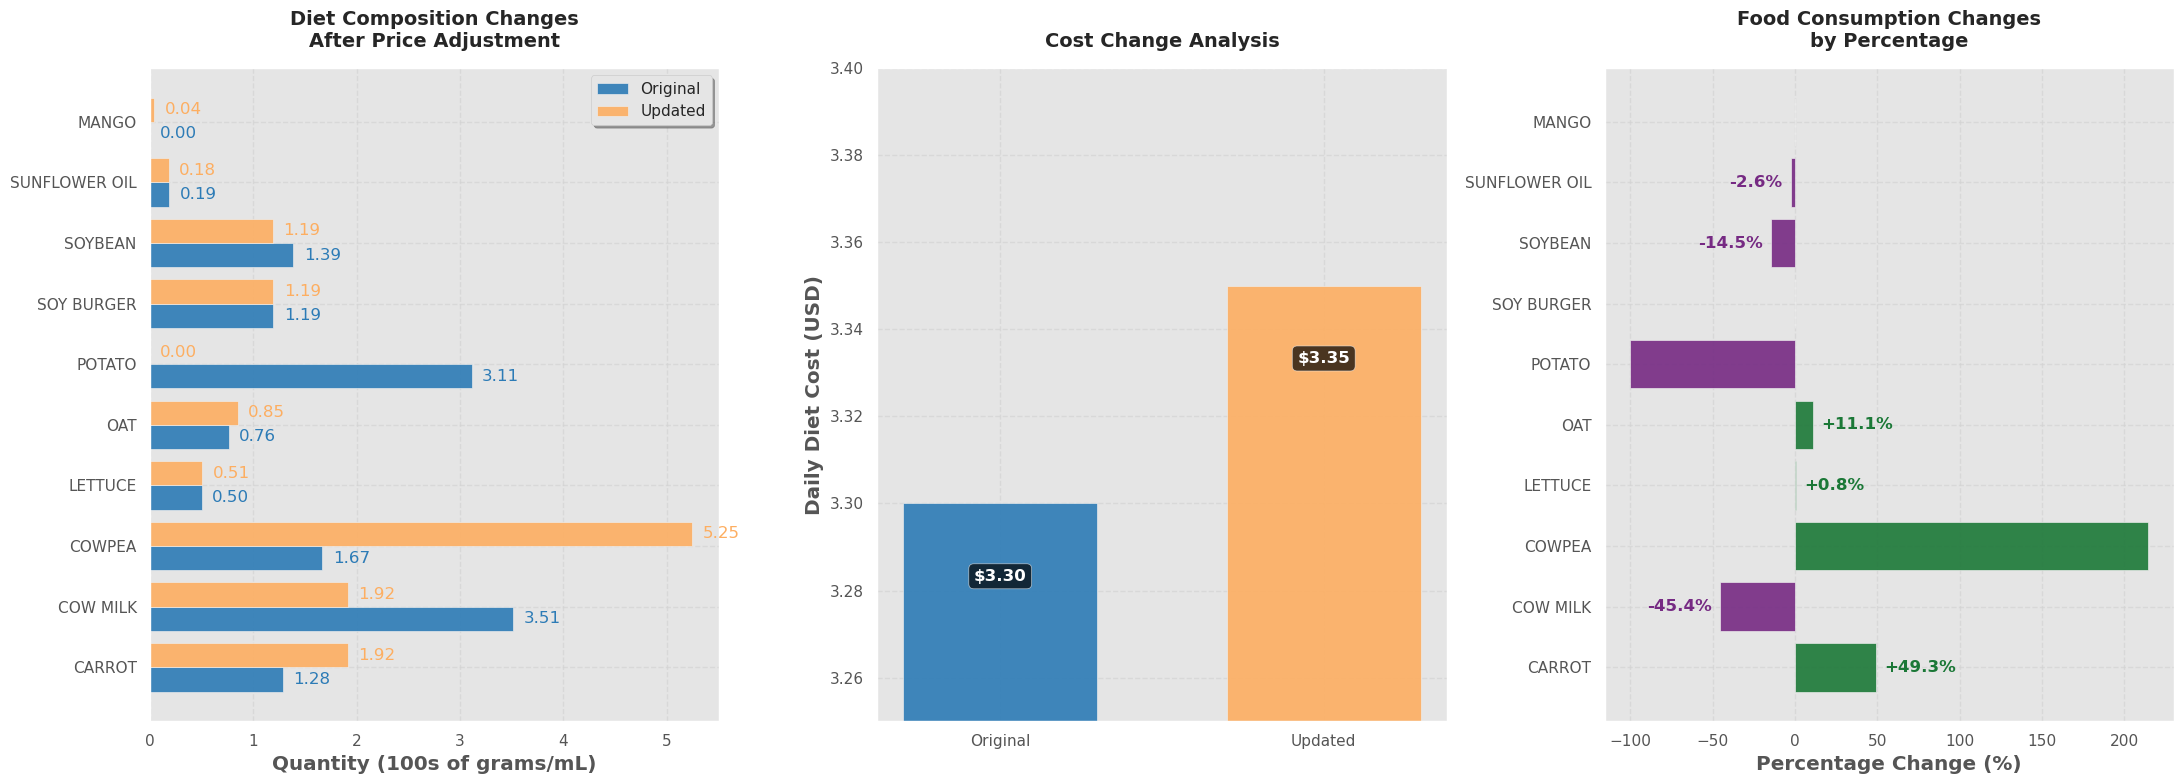

In [74]:
### This is about the Cost of diet for F 19-30

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'DejaVu Sans',
    'grid.color': '#d3d3d3',
    'grid.linestyle': '--',
    'grid.alpha': 0.7
})

fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='white')
plt.subplots_adjust(wspace=0.3)

colors = {
    'original': '#2c7bb6',
    'updated': '#fdae61',
    'increase': '#1b7837',
    'decrease': '#762a83'
}

foods = ["CARROT", "COW MILK", "COWPEA", "LETTUCE", "OAT", 
        "POTATO", "SOY BURGER", "SOYBEAN", "SUNFLOWER OIL", "MANGO"]

original_values = [1.285, 3.514, 1.669, 0.504, 0.764, 
                  3.114, 1.194, 1.389, 0.189, 0]
updated_values = [1.918, 1.919, 5.247, 0.508, 0.849, 
                 0, 1.194, 1.188, 0.184, 0.044]

y = np.arange(len(foods))
bar_width = 0.4

axes[0].barh(y - bar_width/2, original_values, bar_width,
            color=colors['original'], alpha=0.9, label='Original')
axes[0].barh(y + bar_width/2, updated_values, bar_width,
            color=colors['updated'], alpha=0.9, label='Updated')

axes[0].set_yticks(y)
axes[0].set_yticklabels(foods)
axes[0].set_xlabel('Quantity (100s of grams/mL)', fontweight='semibold')
axes[0].set_title('Diet Composition Changes\nAfter Price Adjustment', 
                 fontsize=14, fontweight='bold', pad=15)
axes[0].legend(frameon=True, shadow=True)
axes[0].grid(True, axis='x')

for i, (orig, upd) in enumerate(zip(original_values, updated_values)):
    axes[0].text(orig + 0.1, i - bar_width/2, f'{orig:.2f}', 
                va='center', color=colors['original'])
    axes[0].text(upd + 0.1, i + bar_width/2, f'{upd:.2f}', 
                va='center', color=colors['updated'])

costs = [3.30, 3.35]
labels = ['Original', 'Updated']

bars = axes[1].bar(labels, costs, color=[colors['original'], colors['updated']], 
                  width=0.6, alpha=0.9)

axes[1].set_ylim(3.25, 3.40)
axes[1].set_ylabel('Daily Diet Cost (USD)', fontweight='semibold')
axes[1].set_title('Cost Change Analysis', 
                 fontsize=14, fontweight='bold', pad=15)
axes[1].grid(True, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height-0.015,
                f'${height:.2f}',
                ha='center', va='top',
                color='white', weight='bold',
                bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.3'))

percent_change = [
    ((upd - orig)/orig)*100 if orig != 0 else 0 
    for orig, upd in zip(original_values, updated_values)
]

hide_labels = {"POTATO", "COWPEA"}

bar_colors = [colors['increase'] if pc > 0 else colors['decrease'] for pc in percent_change]

bars = axes[2].barh(foods, percent_change, color=bar_colors, alpha=0.9)
axes[2].set_xlabel('Percentage Change (%)', fontweight='semibold')
axes[2].set_title('Food Consumption Changes\nby Percentage', 
                 fontsize=14, fontweight='bold', pad=15)
axes[2].grid(True, axis='x')

for bar, food, pc in zip(bars, foods, percent_change):
    width = bar.get_width()
    if width != 0 and food not in hide_labels:
        label = f"{width:+.1f}%"
        position = width + 5 if width > 0 else width - 5
        axes[2].text(position, bar.get_y() + bar.get_height()/2,
                    label,
                    va='center', ha='left' if width > 0 else 'right',
                    color=colors['increase'] if width > 0 else colors['decrease'],
                    weight='bold')

plt.tight_layout()
plt.show()